已经生成：digit_1.png


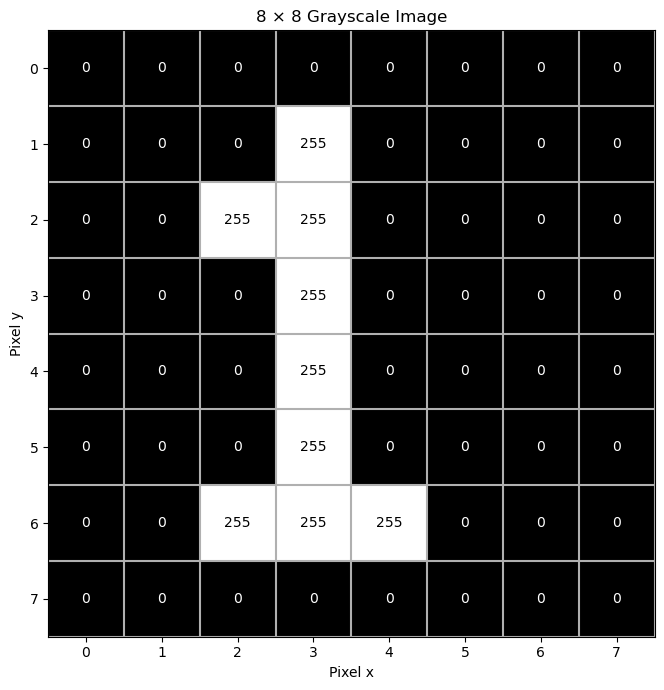


PNG 读取后的 NumPy 数组
[[  0   0   0   0   0   0   0   0]
 [  0   0   0 255   0   0   0   0]
 [  0   0 255 255   0   0   0   0]
 [  0   0   0 255   0   0   0   0]
 [  0   0   0 255   0   0   0   0]
 [  0   0   0 255   0   0   0   0]
 [  0   0 255 255 255   0   0   0]
 [  0   0   0   0   0   0   0   0]]

NumPy shape: (8, 8)
NumPy dtype: uint8

转换成 PyTorch Tensor 后
tensor([[[0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 1., 0., 0., 0., 0.],
         [0., 0., 1., 1., 0., 0., 0., 0.],
         [0., 0., 0., 1., 0., 0., 0., 0.],
         [0., 0., 0., 1., 0., 0., 0., 0.],
         [0., 0., 0., 1., 0., 0., 0., 0.],
         [0., 0., 1., 1., 1., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.]]])

Tensor shape: torch.Size([1, 8, 8])
Tensor dtype: torch.float32
Tensor 最小值: tensor(0.)
Tensor 最大值: tensor(1.)

增加 batch 维度后
torch.Size([1, 1, 8, 8])


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torchvision import transforms


# ============================================================
# 1. 手动构造一张 8 × 8 的灰度图片 0 = 黑色，255 = 白色
image_array = np.array([
    [0, 0,   0,   0,   0, 0, 0, 0],
    [0, 0,   0, 255,   0, 0, 0, 0],
    [0, 0, 255, 255,   0, 0, 0, 0],
    [0, 0,   0, 255,   0, 0, 0, 0],
    [0, 0,   0, 255,   0, 0, 0, 0],
    [0, 0,   0, 255,   0, 0, 0, 0],
    [0, 0, 255, 255, 255, 0, 0, 0],
    [0, 0,   0,   0,   0, 0, 0, 0],
], dtype=np.uint8)


# ============================================================
# 2. NumPy 数组 → PNG 图片

image = Image.fromarray(image_array, mode="L")
image.save("digit_1.png")
print("已经生成：digit_1.png")


# ============================================================
# 3. 显示图片、像素块边界和每个像素的数值

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(image_array, cmap="gray", vmin=0, vmax=255, interpolation="nearest")

# 像素编号
ax.set_xticks(np.arange(8))
ax.set_yticks(np.arange(8))
ax.set_xlabel("Pixel x")
ax.set_ylabel("Pixel y")

# 像素边界位于 -0.5, 0.5, 1.5, ..., 7.5
ax.set_xticks(np.arange(-0.5, 8, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 8, 1), minor=True)

# 绘制像素网格
ax.grid(which="minor", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

# 在每个像素中心显示像素值
for row in range(8):
    for col in range(8):
        value = image_array[row, col]
        text_color = "black" if value > 128 else "white"
        ax.text(col, row, str(value), ha="center", va="center", color=text_color, fontsize=10)

ax.set_title("8 × 8 Grayscale Image")

plt.tight_layout()
plt.show()


# ============================================================
# 4. 从 PNG 文件重新读取，并转换成 NumPy 数组

image_read = Image.open("digit_1.png").convert("L")
array_read = np.array(image_read)

print("\n========================================")
print("PNG 读取后的 NumPy 数组")
print("========================================")

print(array_read)
print("\nNumPy shape:", array_read.shape)
print("NumPy dtype:", array_read.dtype)


# ============================================================
# 5. PNG → PyTorch Tensor
# ToTensor()：
# (H, W) → (C, H, W) C是一个灰度通道，H是高度8个像素，W是宽度8个像素
# 但是神经网络一次会处理多个图片，例如一次处理64张
# (N,C,H,W),N就是batch size，一次处理64个图，N就取64
# uint8: 0~255 → float32: 0~1
# ============================================================

transform = transforms.ToTensor()
tensor = transform(image_read)

print("\n========================================")
print("转换成 PyTorch Tensor 后")
print("========================================")

print(tensor)
print("\nTensor shape:", tensor.shape)
print("Tensor dtype:", tensor.dtype)
print("Tensor 最小值:", tensor.min())
print("Tensor 最大值:", tensor.max())


# ============================================================
# 6. 增加 batch 维度
# Conv2d 输入格式：(N, C, H, W)
# (1, 8, 8) → (1, 1, 8, 8)
# ============================================================

tensor_batch = tensor.unsqueeze(0)

print("\n========================================")
print("增加 batch 维度后")
print("========================================")

print(tensor_batch.shape)

已经生成：digit_1_color.png


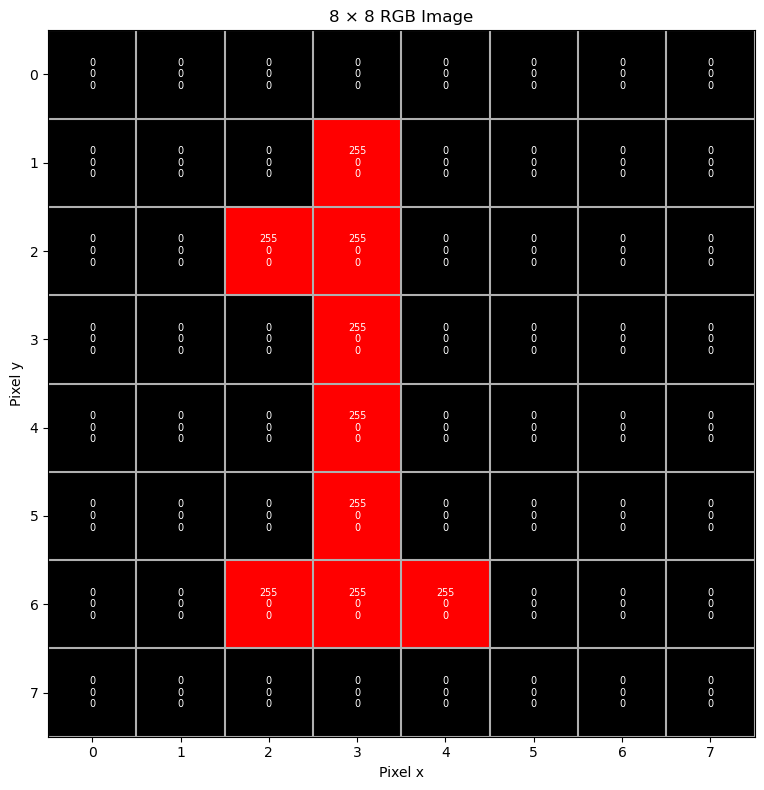


转换成 PyTorch Tensor 后
tensor([[[0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 1., 0., 0., 0., 0.],
         [0., 0., 1., 1., 0., 0., 0., 0.],
         [0., 0., 0., 1., 0., 0., 0., 0.],
         [0., 0., 0., 1., 0., 0., 0., 0.],
         [0., 0., 0., 1., 0., 0., 0., 0.],
         [0., 0., 1., 1., 1., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.]]])

Tensor shape: torch.Size([1, 8, 8])
Tensor dtype: torch.float32
Tensor 最小值: tensor(0.)
Tensor 最大值: tensor(1.)

增加 batch 维度后
torch.Size([1, 1, 8, 8])


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torchvision import transforms


# ============================================================
# 1. 构造一张 8 × 8 RGB 彩色图片
# 每个像素包含三个数字：(R, G, B)
# 黑色 = (0, 0, 0) 红色 = (255, 0, 0)
# ============================================================

image_array = np.zeros((8, 8, 3), dtype=np.uint8) #创建一个形状为(8,8,3)的numpy数组

# 用红色像素画数字 "1"
red = [255, 0, 0]
#把第i行第j列的像素改成红色
image_array[1, 3] = red
image_array[2, 2] = red
image_array[2, 3] = red
image_array[3, 3] = red
image_array[4, 3] = red
image_array[5, 3] = red
image_array[6, 2] = red
image_array[6, 3] = red
image_array[6, 4] = red


# ============================================================
# 2. NumPy 数组 → RGB PNG

image = Image.fromarray(image_array, mode="RGB")
image.save("digit_1_color.png")
print("已经生成：digit_1_color.png")


# ============================================================
# 3. 显示图片、像素边界和 RGB 数值

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image_array, interpolation="nearest")

ax.set_xticks(np.arange(8))
ax.set_yticks(np.arange(8))
ax.set_xlabel("Pixel x")
ax.set_ylabel("Pixel y")

ax.set_xticks(np.arange(-0.5, 8, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 8, 1), minor=True)
ax.grid(which="minor", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

# 显示每个像素的 RGB 数值
for row in range(8):
    for col in range(8):
        r, g, b = image_array[row, col]
        text = f"{r}\n{g}\n{b}"
        text_color = "black" if (r + g + b) > 400 else "white"
        ax.text(col, row, text, ha="center", va="center", color=text_color, fontsize=7)

ax.set_title("8 × 8 RGB Image")
plt.tight_layout()
plt.show()



# ============================================================
# 5. RGB PNG → PyTorch Tensor
# NumPy / PNG：
# (H, W, C) = (8, 8, 3)
# PyTorch：
# (C, H, W) = (3, 8, 8)
# 同时：
# 0~255 → 0~1
# ============================================================

transform = transforms.ToTensor()
tensor = transform(image_read)

print("\n========================================")
print("转换成 PyTorch Tensor 后")
print("========================================")

print(tensor)
print("\nTensor shape:", tensor.shape)
print("Tensor dtype:", tensor.dtype)
print("Tensor 最小值:", tensor.min())
print("Tensor 最大值:", tensor.max())


# ============================================================
# 6. 增加 batch 维度
# (C, H, W)
# (3, 8, 8)
# ↓
# (N, C, H, W)
# (1, 3, 8, 8)
# ============================================================

tensor_batch = tensor.unsqueeze(0)

print("\n========================================")
print("增加 batch 维度后")
print("========================================")

print(tensor_batch.shape)

### 随机生成圆、方块、三角形图片，让 CNN/U-Net 输入原图，输出物体轮廓

#### 生成图片到本地

生成完成：1200 张图片
Input images: shape_dataset/images
Masks: shape_dataset/masks


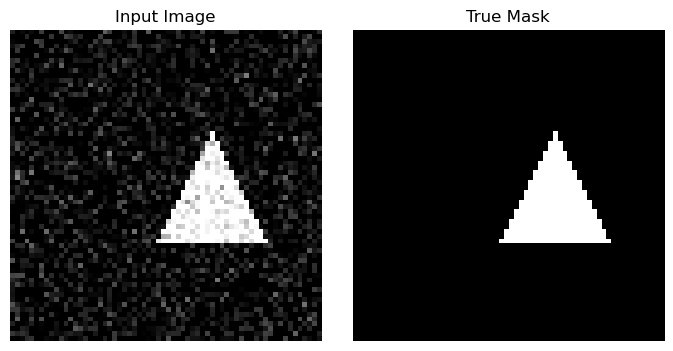

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from pathlib import Path

# ============================================================
# 1. 参数
# ============================================================

IMAGE_SIZE = 64
N_IMAGES = 1200

root_dir = Path("shape_dataset")
image_dir = root_dir / "images"
mask_dir = root_dir / "masks"

image_dir.mkdir(parents=True, exist_ok=True)
mask_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. 随机生成圆、方块、三角形
# ============================================================

def generate_shape():
    mask = Image.new("L", (IMAGE_SIZE, IMAGE_SIZE), 0)
    draw = ImageDraw.Draw(mask)

    shape_type = np.random.choice(["circle", "square", "triangle"])
    cx = np.random.randint(18, 46)
    cy = np.random.randint(18, 46)
    size = np.random.randint(10, 18)

    if shape_type == "circle":
        draw.ellipse([cx-size, cy-size, cx+size, cy+size], fill=255)

    elif shape_type == "square":
        draw.rectangle([cx-size, cy-size, cx+size, cy+size], fill=255)

    elif shape_type == "triangle":
        points = [(cx, cy-size), (cx-size, cy+size), (cx+size, cy+size)]
        draw.polygon(points, fill=255)

    mask_array = np.array(mask, dtype=np.float32) / 255.0
    noise = np.random.normal(0, 0.15, mask_array.shape).astype(np.float32)
    image_array = np.clip(mask_array + noise, 0.0, 1.0)

    return image_array, mask_array


# ============================================================
# 3. 生成并保存
# ============================================================

for i in range(N_IMAGES):
    image_array, mask_array = generate_shape()

    image_uint8 = (image_array * 255).astype(np.uint8)
    mask_uint8 = (mask_array * 255).astype(np.uint8)

    Image.fromarray(image_uint8, mode="L").save(image_dir / f"{i:05d}.png")
    Image.fromarray(mask_uint8, mode="L").save(mask_dir / f"{i:05d}.png")

print(f"生成完成：{N_IMAGES} 张图片")
print("Input images:", image_dir)
print("Masks:", mask_dir)


# ============================================================
# 4. 随机查看一个样本
# ============================================================

index = np.random.randint(0, N_IMAGES)

image = Image.open(image_dir / f"{index:05d}.png")
mask = Image.open(mask_dir / f"{index:05d}.png")

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))

axes[0].imshow(image, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Input Image")

axes[1].imshow(mask, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("True Mask")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

#### 读取数据并定义Tiny U-Net

In [5]:
import torch
import torch.nn as nn

from PIL import Image
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
# ============================================================
# 1. Dataset
# ============================================================

class ShapeDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = Path(root_dir)
        self.image_dir = self.root_dir / "images"
        self.mask_dir = self.root_dir / "masks"
        self.files = sorted(self.image_dir.glob("*.png"))
        self.transform = transforms.ToTensor()

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        filename = self.files[index].name

        image = Image.open(self.image_dir / filename).convert("L")
        mask = Image.open(self.mask_dir / filename).convert("L")

        image = self.transform(image)
        mask = self.transform(mask)

        return image, mask


# ============================================================
# 2. DataLoader
# ============================================================

dataset = ShapeDataset("shape_dataset")
train_loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)

images, masks = next(iter(train_loader))

print("Images shape:", images.shape)
print("Masks shape :", masks.shape)


# ============================================================
# 3. 两次卷积模块
# ============================================================

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)


# ============================================================
# 4. Tiny U-Net
# ============================================================

class TinyUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = ConvBlock(1, 16)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ConvBlock(16, 32)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(32, 64)

        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(64, 32)

        self.up1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(32, 16)

        self.output = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))

        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.output(d1)


# ============================================================
# 5. 建立模型
# ============================================================

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model = TinyUNet().to(device)

print("\nDevice:", device)
print(model)

Images shape: torch.Size([32, 1, 64, 64])
Masks shape : torch.Size([32, 1, 64, 64])

Device: mps
TinyUNet(
  (enc1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): ConvBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      

#### 训练、Loss、预测 Mask、提取轮廓

Epoch  1/10   Loss = 0.301250
Epoch  2/10   Loss = 0.011909
Epoch  3/10   Loss = 0.005249
Epoch  4/10   Loss = 0.003998
Epoch  5/10   Loss = 0.003362
Epoch  6/10   Loss = 0.002801
Epoch  7/10   Loss = 0.002244
Epoch  8/10   Loss = 0.001868
Epoch  9/10   Loss = 0.001536
Epoch 10/10   Loss = 0.001307


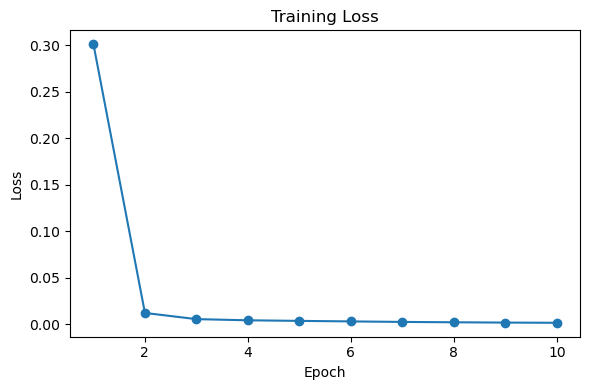

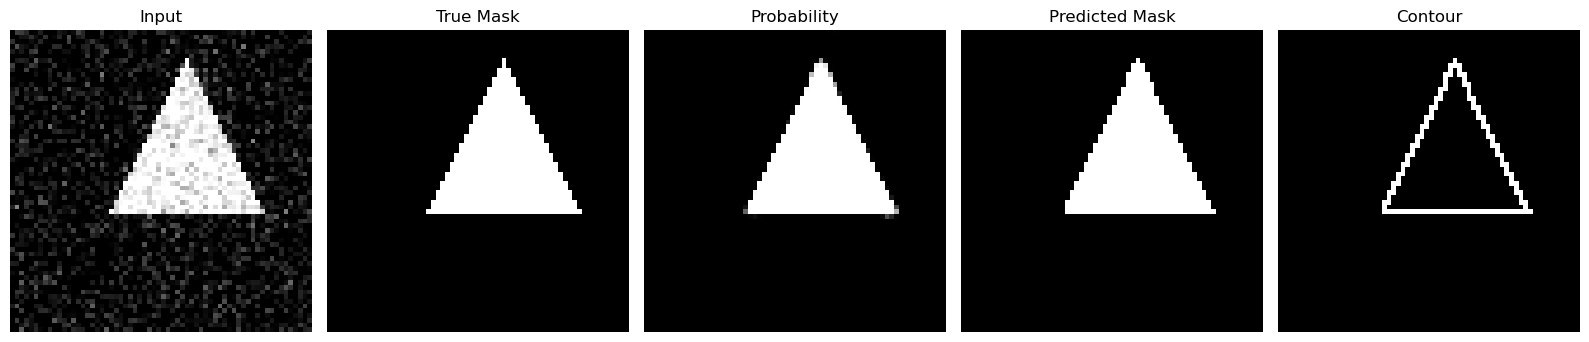

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F


# ============================================================
# 1. 损失函数和优化器
# ============================================================

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 10
loss_history = []


# ============================================================
# 2. 训练
# ============================================================

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    average_loss = total_loss / len(dataset)
    loss_history.append(average_loss)

    print(f"Epoch {epoch:2d}/{EPOCHS}   Loss = {average_loss:.6f}")


# ============================================================
# 3. 绘制 Loss
# ============================================================

plt.figure(figsize=(6, 4))
plt.plot(range(1, EPOCHS + 1), loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.tight_layout()
plt.show()


# ============================================================
# 4. 随机选择一张图片测试
# ============================================================

index = np.random.randint(0, len(dataset))
test_image, test_mask = dataset[index]

x = test_image.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    logits = model(x)
    probability = torch.sigmoid(logits)
    prediction = (probability > 0.5).float()


# ============================================================
# 5. 提取轮廓
#
# mask - 腐蚀后的 mask = 边界
# ============================================================

prediction_cpu = prediction.cpu()

eroded = 1.0 - F.max_pool2d(1.0 - prediction_cpu, kernel_size=3, stride=1, padding=1)
contour = prediction_cpu - eroded


# ============================================================
# 6. 转成二维数组画图
# ============================================================

input_2d = test_image[0].numpy()
true_mask_2d = test_mask[0].numpy()
probability_2d = probability[0, 0].cpu().numpy()
prediction_2d = prediction_cpu[0, 0].numpy()
contour_2d = contour[0, 0].numpy()


# ============================================================
# 7. 显示结果
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))

axes[0].imshow(input_2d, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Input")

axes[1].imshow(true_mask_2d, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("True Mask")

axes[2].imshow(probability_2d, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Probability")

axes[3].imshow(prediction_2d, cmap="gray", vmin=0, vmax=1)
axes[3].set_title("Predicted Mask")

axes[4].imshow(contour_2d, cmap="gray", vmin=0, vmax=1)
axes[4].set_title("Contour")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()